In [4]:
pip install catboost 

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install skimpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


# ***Importing The Necessary Libraries*** 

In [6]:
# Importing required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, accuracy_score, roc_curve, auc, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.models import save_model
import os
from skimpy import skim

dataset link:https://www.kaggle.com/datasets/priyankraval/nurse-stress-prediction-wearable-sensors?select=merged_data.csv
***************************
X, Y, Z: These likely represent accelerometer data in three dimensions (X, Y, Z axes), capturing the motion or position of the sensor device.

EDA: This stands for Electrodermal Activity, which measures the skin's conductance and is often used to infer physiological arousal or stress.

HR: This stands for Heart Rate, measured in beats per minute (BPM), which indicates the user's heart rate at the time of recording.

TEMP: This represents the temperature of the user's body or the surrounding environment, in degrees Celsius.

id: This likely corresponds to a unique identifier for the individual or the device collecting the data.

datetime: This column stores the timestamp of when each data point was recorded.

label: This is likely the target or classification label, which might indicate the health condition or state being assessed in the dataset (e.g., stress levels).


In [7]:
# Load the dataset
data = pd.read_excel('mental stress data.xlsx')

In [8]:
#Reading First 5 rows 
data.head()

,X,Y,Z,EDA,HR,TEMP,id,datetime,label
0,-13,-61,5,6.769995,99.43,31.17,15,08-07-1010 14:03:00,1
1,-10,-69,-3,6.769995,99.43,31.17,15,08-07-1010 14:03:00,1
2,-31,-78,-15,6.769995,99.43,31.17,15,08-07-1010 14:03:00,1
3,-47,-65,-38,6.769995,99.43,31.17,15,08-07-1010 14:03:00,1
4,-67,-57,-53,6.769995,99.43,31.17,15,08-07-1010 14:03:00,1


In [9]:
# Reading the last 5 rows of the dataset
data.tail()

,X,Y,Z,EDA,HR,TEMP,id,datetime,label
100236,-60,15,-11,0.410193,84.63,31.18,15,11-07-1010 16:11:11,1
100237,-60,14,-18,0.410193,84.63,31.18,15,11-07-1010 16:11:11,1
100238,-63,11,-19,0.410193,84.63,31.18,15,11-07-1010 16:11:11,1
100239,-64,11,-13,0.410193,84.63,31.18,15,11-07-1010 16:11:11,1
100240,-61,11,-15,0.410193,84.63,31.18,15,11-07-1010 16:11:11,1


***Knowing the info the dataset***

In [10]:

skim(data)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 100241 │ │ int32       │ 5     │                                                          │
│ │ Number of columns │ 9      │ │ float64     │ 3     │                                                          │
│ └───────────────────┴────────┘ │ string      │ 1     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓  │
│ ┃ column_name    ┃ NA  ┃ NA %   ┃ mean     ┃ sd       ┃ p0     ┃ p25    ┃ p50    ┃ p75    ┃ p100   ┃ hist    ┃  │
│ ┡━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩  │
│ │ X              │   0 │      0 │   -39.03 │    23.52 │   -119 │    -57 │    -44 │    -18 │    111 │   ▇▆▁   │  │
│ │ Y              │   0 │      0 │    6.947 │    29.15 │   -119 │     -8 │      3 │     18 │    117 │   ▁▅▇▃  │  │
│ │ Z              │   0 │      0 │    14.38 │    31.59 │   -118 │     -6 │     16 │     41 │    117 │   ▂▃▇▅  │  │
│ │ EDA            │   0 │      0 │    3.652 │    1.722 │      0 │  1.981 │  4.062 │  4.894 │  7.478 │  ▃▂▃▇▅  │  │
│ │ HR             │   0 │      0 │    85.85 │    11.36 │  64.35 │  78.68 │  81.88 │  93.85 │  134.8 │  ▃▇▃▂   │  │
│ │ TEMP           │   0 │      0 │    32.95 │    1.209 │     31 │  31.66 │  33.45 │  34.11 │  34.66 │ ▅▆ ▁▅▇  │  │
│ │ id             │   0 │      0 │       15 │        0 │     15 │     15 │     15 │     15 │     15 │     ▇   │  │
│ │ label          │   0 │      0 │   0.8659 │   0.3407 │      0 │      1 │      1 │      1 │      1 │ ▁    ▇  │  │
│ └────────────────┴─────┴────────┴──────────┴──────────┴────────┴────────┴────────┴────────┴────────┴─────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┓  │
│ ┃ column_name               ┃ NA      ┃ NA %       ┃ words per row                ┃ total words              ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━┩  │
│ │ datetime                  │       0 │          0 │                            3 │                   300723 │  │
│ └───────────────────────────┴─────────┴────────────┴──────────────────────────────┴──────────────────────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

Dataset Overview
Total Rows: 100,241
Total Columns: 9
***********************
Data Types
The dataset contains the following data types:
Integer (int32): 5 columns
Float (float64): 3 columns
String: 1 column
**************************
Column Descriptions
X
Type: Float
Mean: -39.03
Standard Deviation (SD): 23.52
Min Value (P0): -119
25th Percentile (P25): -57
Median (P50): -44
75th Percentile (P75): -18
Max Value (P100): 111
Missing Values: 0 (0%)
Histogram: The distribution shows a slight skew, with values ranging significantly in the negative direction.
*****************************
Y
Type: Float
Mean: 6.947
SD: 29.15
Min Value (P0): -119
P25: -8
P50: 3
P75: 18
P100: 117
Missing Values: 0 (0%)
Histogram: The distribution is skewed towards the left, indicating a range of low to high values.
*******************************
Z
Type: Float
Mean: 14.38
SD: 31.59
Min Value (P0): -118
P25: -6
P50: 16
P75: 41
P100: 117
Missing Values: 0 (0%)
Histogram: Similar to Y, with a notable range of values, including negative and positive.
***********************************
EDA (Electrodermal Activity)
Type: Float
Mean: 3.652
SD: 1.722
Min Value (P0): 0
P25: 1.981
P50: 4.062
P75: 4.894
P100: 7.478
Missing Values: 0 (0%)
Histogram: Distribution shows most values are clustered around 1.981 to 4.894, with a noticeable upper limit.
***************************************
HR (Heart Rate)
Type: Float
Mean: 85.85
SD: 11.36
Min Value (P0): 64.35
P25: 78.68
P50: 81.88
P75: 93.85
P100: 134.8
Missing Values: 0 (0%)
Histogram: The distribution appears normal with a concentration of heart rates around the mean.
***************************************
TEMP (Temperature)
Type: Float
Mean: 32.95
SD: 1.209
Min Value (P0): 31
P25: 31.66
P50: 33.45
P75: 34.11
P100: 34.66
Missing Values: 0 (0%)
Histogram: The values show a tight cluster, indicating consistent temperature readings.
*******************************************
id
Type: Integer
Mean: 15
SD: 0
Min Value (P0): 15
P25: 15
P50: 15
P75: 15
P100: 15
Missing Values: 0 (0%)
Histogram: This column appears to be constant across the dataset, indicating it may serve as an index or identifier.
******************************************
label (Target Variable)
Type: Float
Mean: 0.8659
SD: 0.3407
Min Value (P0): 0
P25: 1
P50: 1
P75: 1
P100: 1
Missing Values: 0 (0%)
Histogram: The majority of instances are labeled as 1, suggesting a possible class imbalance.
******************************************
datetime
Type: String (presumably datetime)
Missing Values: 0 (0%)
Words per Row: 3
Total Words: 300,723
This column contains timestamp information, which may be useful for time-based analysis.
*****************************************
Summary of Insights
The dataset appears to be well-structured with no missing values across all columns, indicating a high level of data completeness.
The numerical features (X, Y, Z, EDA, HR, TEMP) have varied ranges and distributions, suggesting that feature scaling may be beneficial before training any machine learning models.
The label column indicates that the target variable is likely a binary classification problem, with a class imbalance favoring one class.
The datetime column can provide contextual information for analysis, especially if the stress levels are expected to vary over time.

# ***1. Preprocessing the dataset***

In [11]:

# Dropping unnecessary columns such as 'id', 'datetime'
data.drop(['id', 'datetime'], axis=1, inplace=True)


In [12]:
# knowing the columns in the dataset after dropping the unrelated columns
data.columns

Index(['X', 'Y', 'Z', 'EDA', 'HR', 'TEMP', 'label'], dtype='object')

In [13]:
# Save the DataFrame to an Excel file
data.to_excel('new_features_data.xlsx', index=False)

In [14]:
# To check if there are any null values in the dataset
data.isna().sum()

X        0
Y        0
Z        0
EDA      0
HR       0
TEMP     0
label    0
dtype: int64

In [15]:
# Handling missing values if any
data.fillna(method='ffill', inplace=True)

C:\Users\0931\AppData\Local\Temp\ipykernel_21060\604989988.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)


# ***2. Exploratory Data Analysis (EDA)***

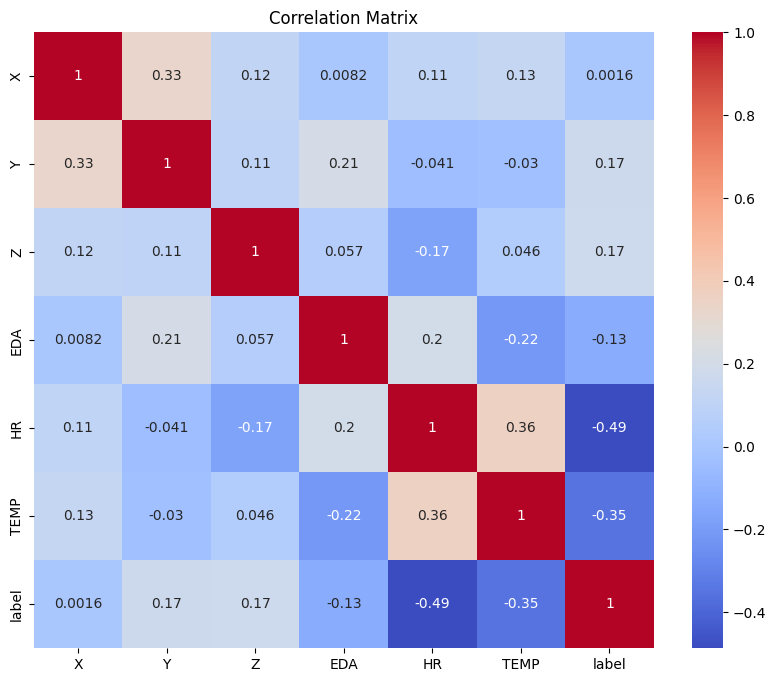

In [16]:

# Correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

1. Correlation Matrix
The correlation matrix is a visual representation of the linear relationships between different features in your dataset. The matrix is color-coded to highlight the strength and direction of these correlations.

Overview:
The correlation values range from -1 to 1. A value of 1 indicates a perfect positive correlation, -1 indicates a perfect negative correlation, and 0 indicates no correlation.
Dark red squares represent strong positive correlations, while dark blue squares represent strong negative correlations.

Key Insights:
X and Y: There is a moderate positive correlation (0.33), indicating that as X increases, Y tends to increase as well.
Y and Z: A similar positive correlation (0.11) exists between these two features.
HR and TEMP: This pair shows a moderate positive correlation (0.36), suggesting that heart rate increases with temperature.
label and other features: The label shows a weak positive correlation with HR (0.17) and a weak negative correlation with TEMP (-0.35), indicating some relationship with stress levels but not strong.

Conclusion:
The matrix helps identify which features may be useful in predicting stress levels (label) based on their correlations. For example, while HR has some positive correlation with the label, TEMP does not, suggesting it may not be a strong predictor of stress.

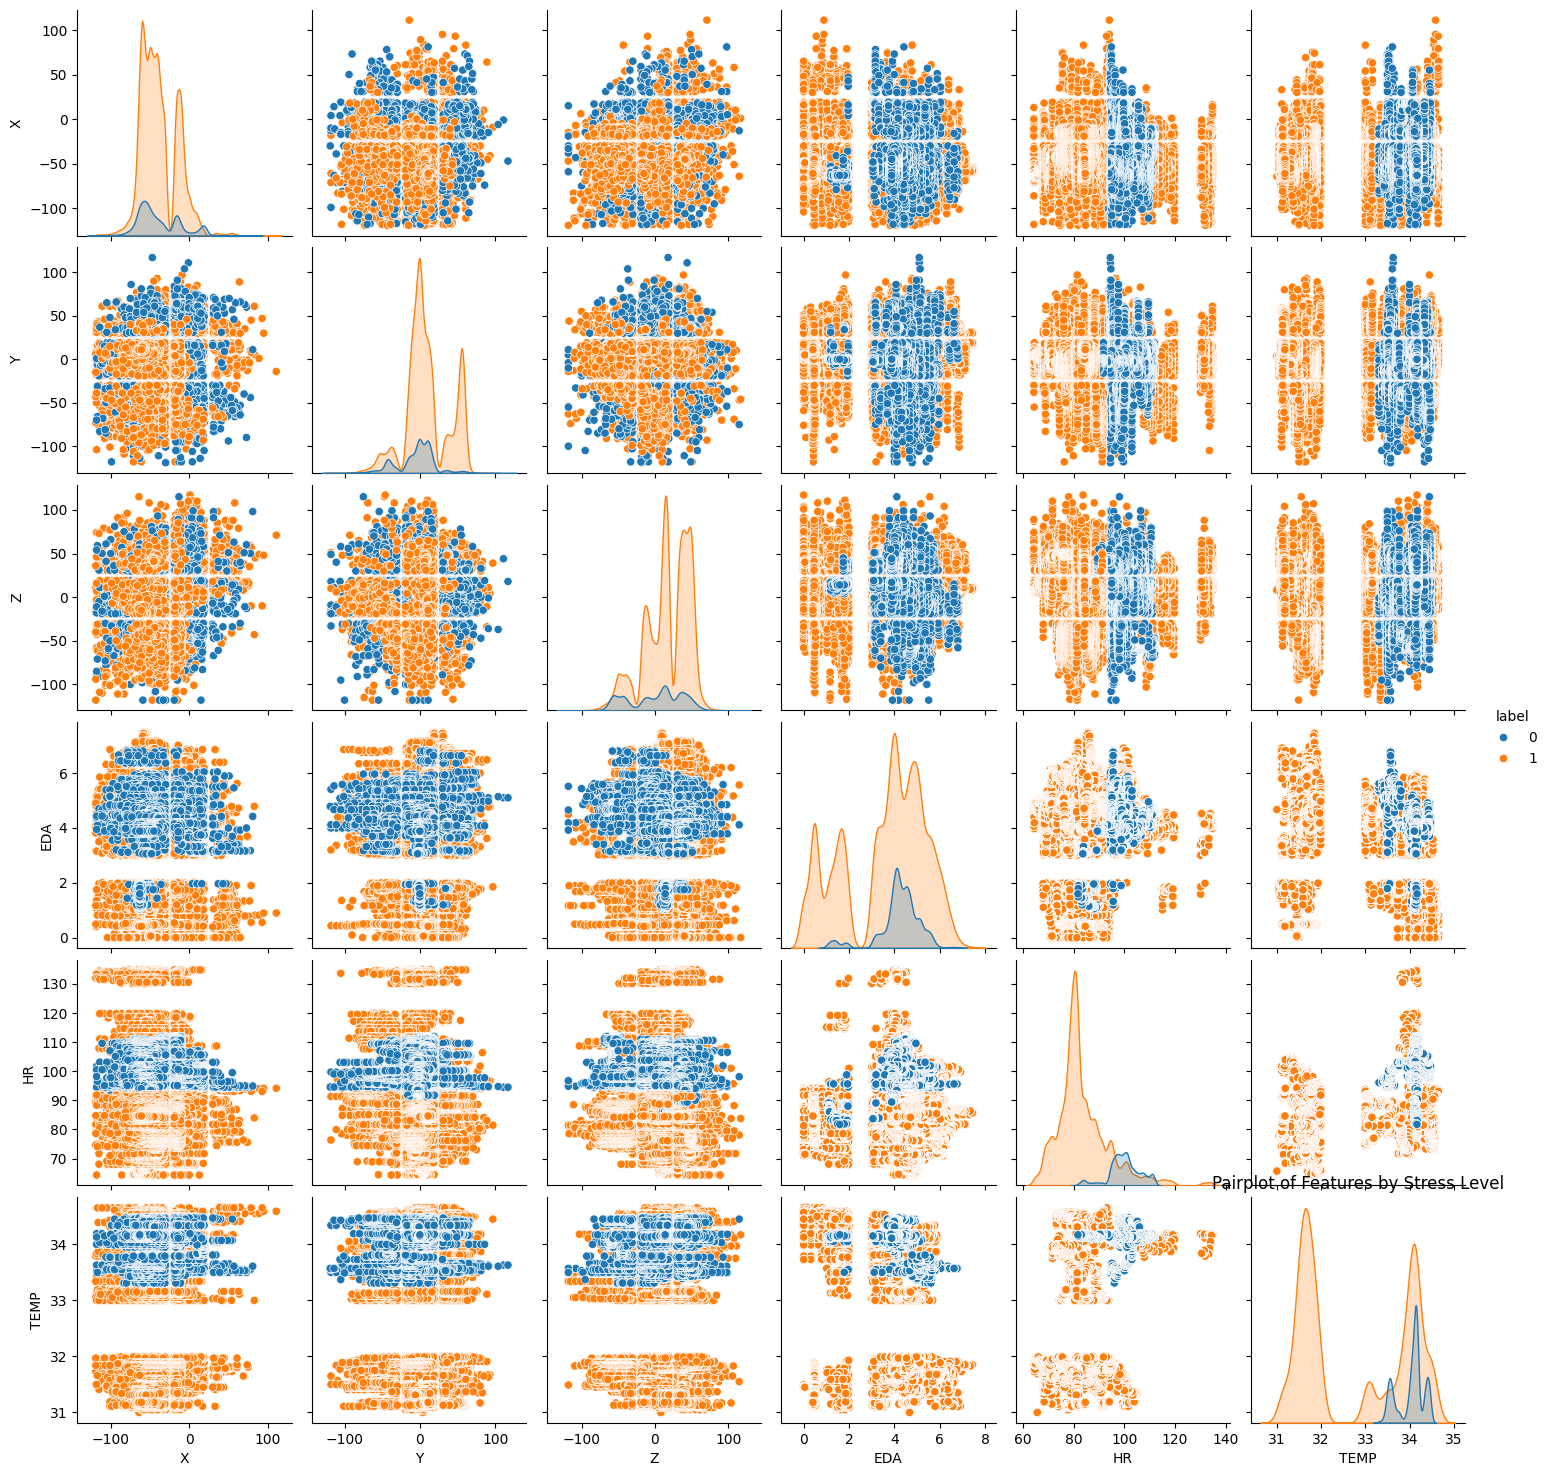

In [17]:
# Pairplot for feature relationships
sns.pairplot(data, hue='label')
plt.title('Pairplot of Features by Stress Level')
plt.show()

2. Pairplot of Features by Stress Level
The pairplot visualizes the relationships between all features in your dataset, segregating points by the stress level label (0 or 1).

Overview:

Each cell in the matrix represents the scatter plot of two features, with the diagonal showing the distribution of individual features.
Points are color-coded (e.g., blue for label 0 and orange for label 1).

Key Insights:

Distribution: The pairplots indicate distinct clustering of points based on the label, especially visible in EDA vs. HR, EDA vs. TEMP, and X vs. Y scatter plots.
Variability: Features like EDA and HR show noticeable patterns where different stress levels lead to different distributions, suggesting these could be important predictors for stress levels.
Outliers: Certain features show significant outliers, which could affect model training if not handled properly.

Conclusion:

This visualization highlights potential relationships and interactions between features that could be important for building predictive models, as well as the effectiveness of EDA as an indicator of stress levels.



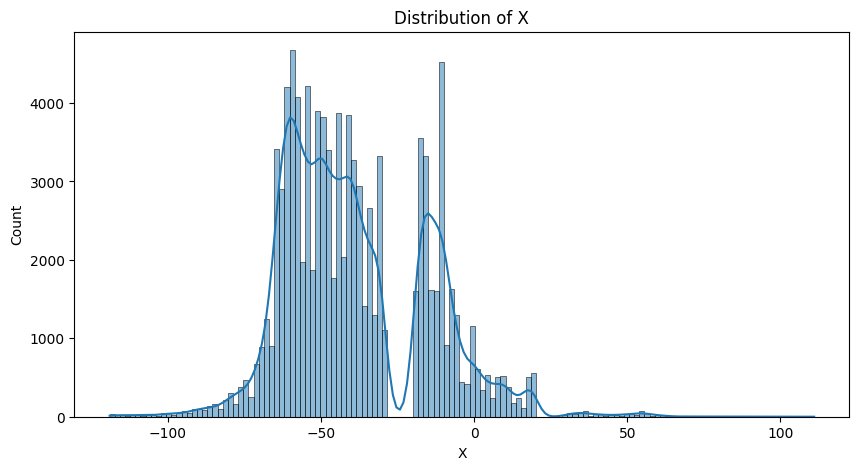

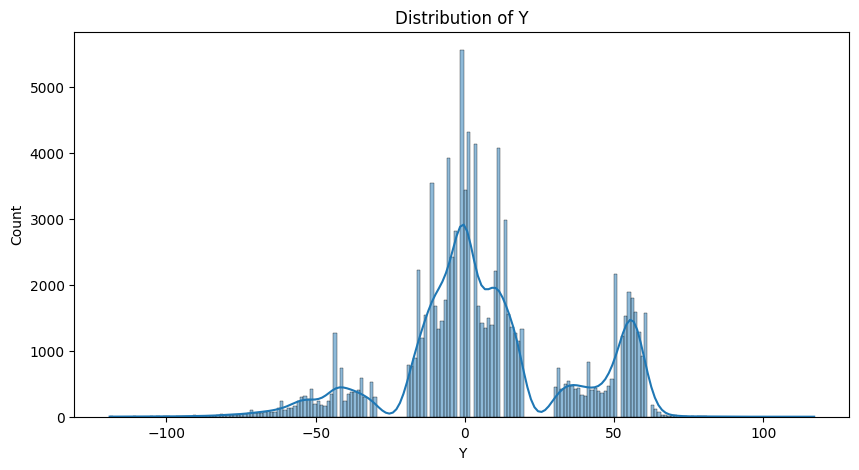

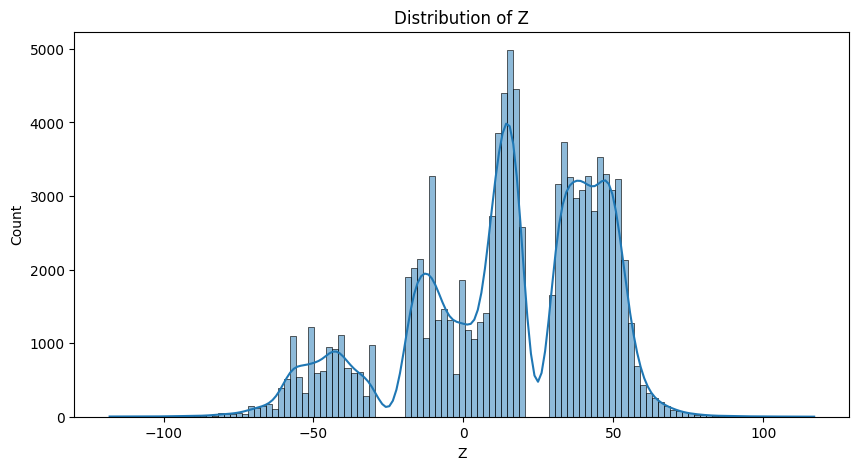

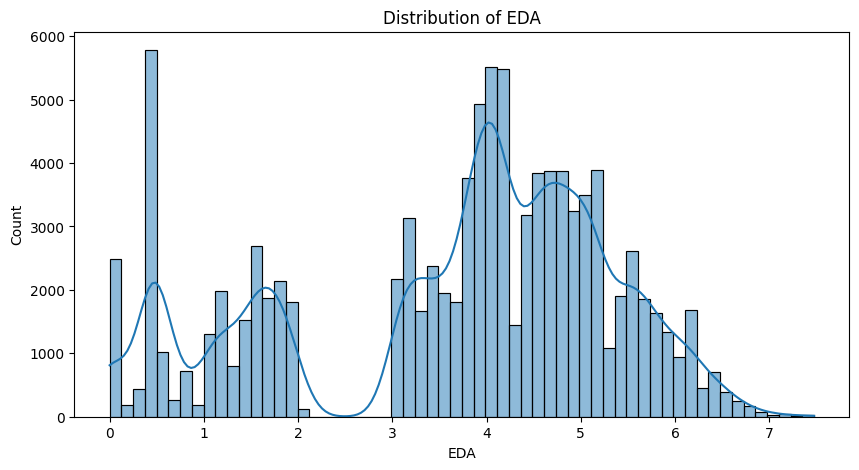

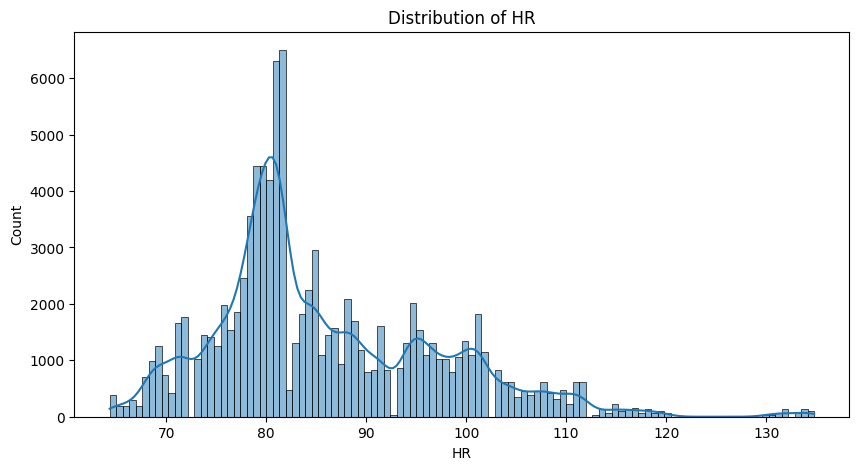

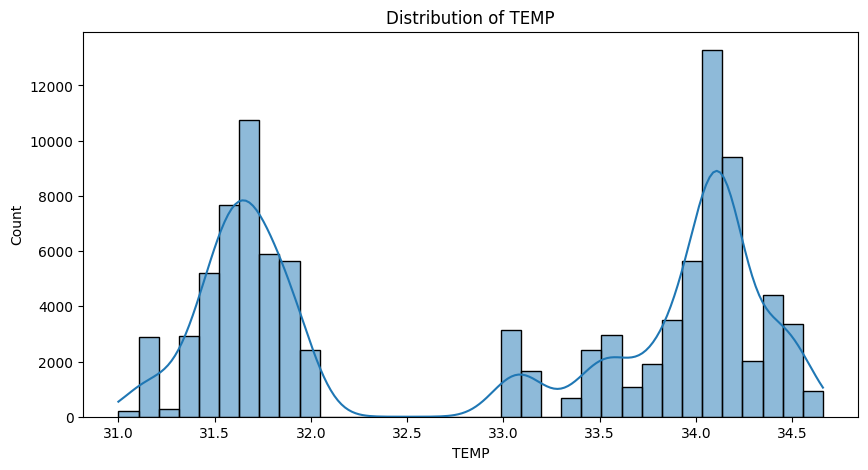

In [18]:

# Histograms for each feature
for column in data.columns[:-1]:  # Exclude the target 'label'
    plt.figure(figsize=(10, 5))
    sns.histplot(data[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.show()

3. Distribution of X
This histogram displays the distribution of values for the feature X.
Overview:
The histogram shows how frequently different ranges of values occur within the dataset for feature X.
A kernel density estimate (KDE) curve overlays the histogram, providing a smooth estimate of the distribution.
    Key Insights:
    Bimodal Distribution: The distribution appears to be bimodal, with two peaks, suggesting two different subgroups or states present within the data.
    Range: The values span a wide range, with significant frequency at both the low and high ends.
    Conclusion:
    Understanding the distribution can aid in deciding how to preprocess the data and which machine learning algorithms may be most appropriate, particularly if certain algorithms perform better with normally distributed features.

4. Distribution of Y
Similar to the distribution of X, this histogram visualizes the frequency of values for feature Y.
Overview:
It exhibits a multimodal distribution, suggesting various distinct states or conditions represented in the data.

    Key Insights:
    Peak Frequencies: There are several peaks, indicating multiple prevalent ranges of values, which might be indicative of various physiological states or responses.
    Symmetry: The distribution is skewed, with more frequent lower values, which may suggest a prevalence of lower readings.
    Conclusion:
    The insights derived from this distribution can help in crafting more informed hypotheses regarding the relationships between physiological states and stress.

5. Distribution of Z
The histogram for feature Z similarly shows its distribution across the dataset.
Overview:
This distribution again appears to be bimodal, with two noticeable peaks and a mix of lower and higher values.
    Key Insights:
    Frequency: There are more occurrences of mid-range values, yet extreme values also hold significant frequency, indicating potential outlier influence.
    Conclusion:
    Identifying how values of Z are distributed can inform feature engineering decisions and model choices, particularly regarding sensitivity to outliers.

6. Distribution of EDA
This histogram illustrates the distribution of Electrodermal Activity (EDA) readings.
Overview:
The distribution showcases a multimodal pattern with several peaks.
    Key Insights:
    Peaks and Variance: Several prominent peaks indicate various physiological responses, which can correspond to different levels of stress or arousal states.
    Bimodality: The presence of low and high values may reflect normal fluctuations in EDA, indicating a wide range of emotional responses.
    Conclusion:
    This feature may serve as a strong indicator of stress levels, with distinct thresholds corresponding to various states of arousal or stress.

7. Distribution of HR
The histogram shows the distribution of heart rate (HR) values in the dataset.
    Overview:
    The histogram displays a right-skewed distribution, with more occurrences of lower heart rate readings.
    Key Insights:
    Prevalent Range: The most common HR values are clustered between 70 to 90 bpm, with fewer instances of very high readings.
    Variability: The presence of a long tail on the right indicates occasional high heart rate values that might signify stress or physical exertion.
    Conclusion:
    This distribution highlights heart rate's potential utility as a predictor for stress levels, particularly as heart rates tend to rise with increasing stress.

8. Distribution of TEMP
This histogram represents the distribution of temperature readings in the dataset.
Overview:
The temperature feature displays a more symmetric distribution, likely indicating typical bodily temperature variations.
    Key Insights:
    Clustered Values: The majority of temperatures range between 31 and 35 degrees Celsius, which is normal for the human body.
    Variability: Slight variations at both ends, but the main cluster suggests stable environmental or physiological conditions.
    Conclusion:
    While temperature is typically stable, its relationship with other features could still provide insights into physiological responses, especially when correlated with stress levels.

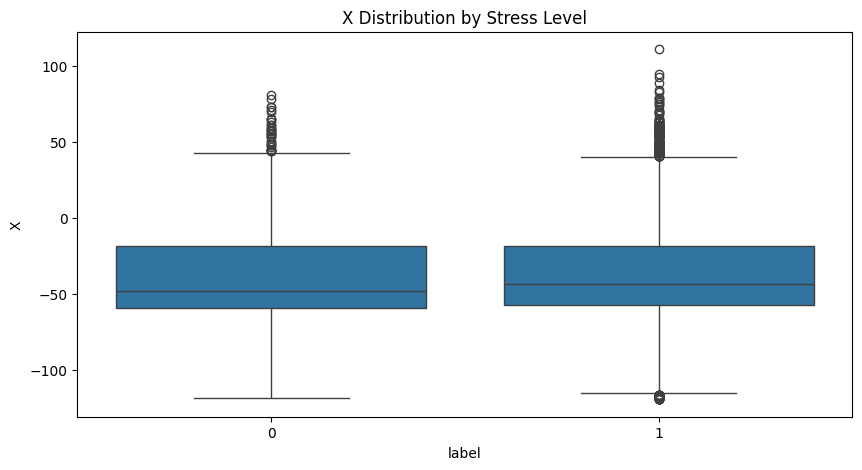

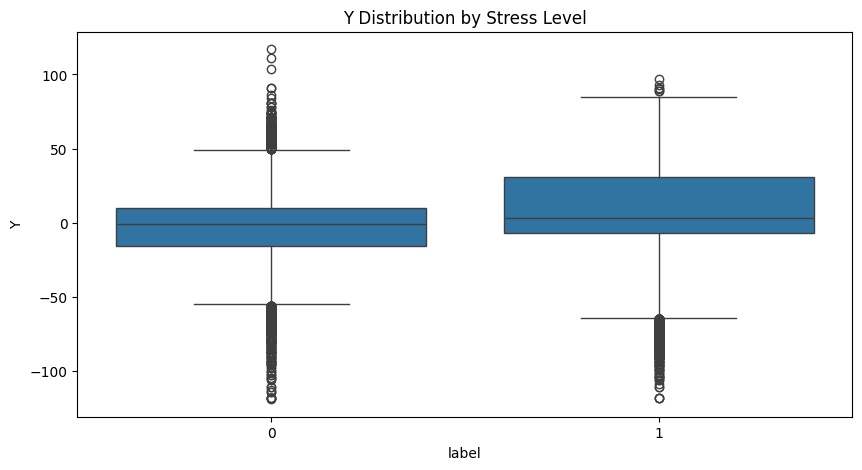

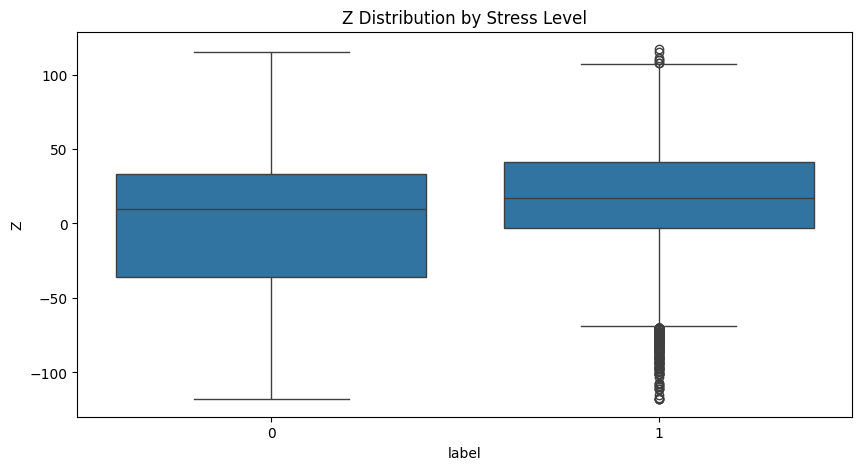

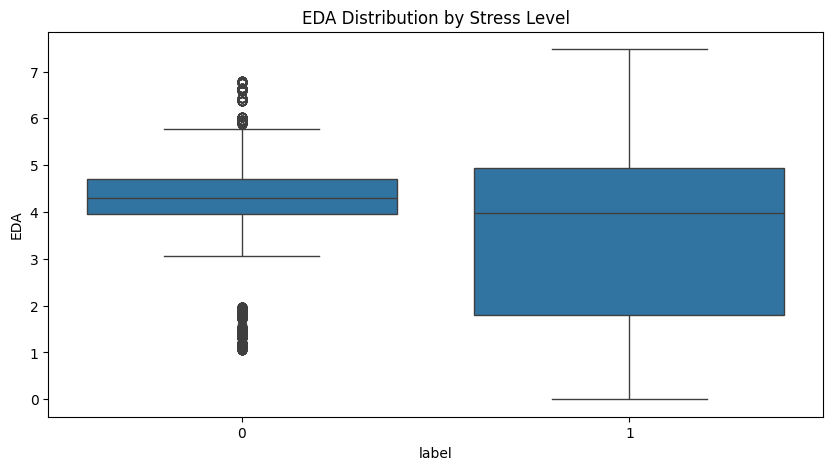

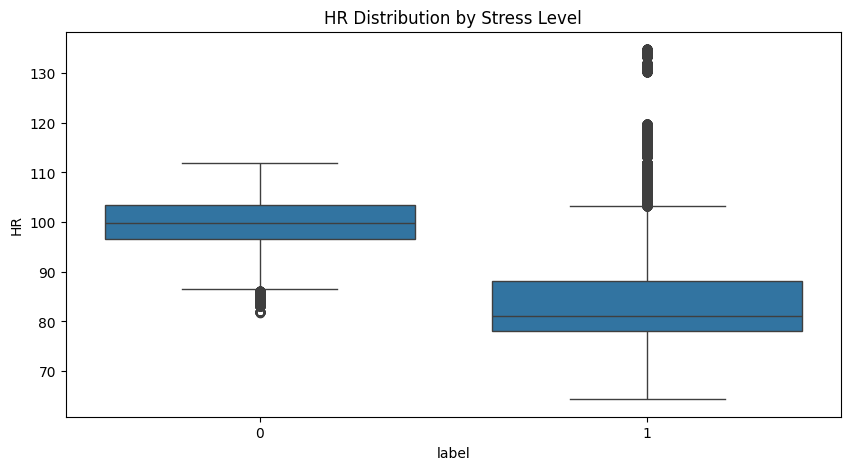

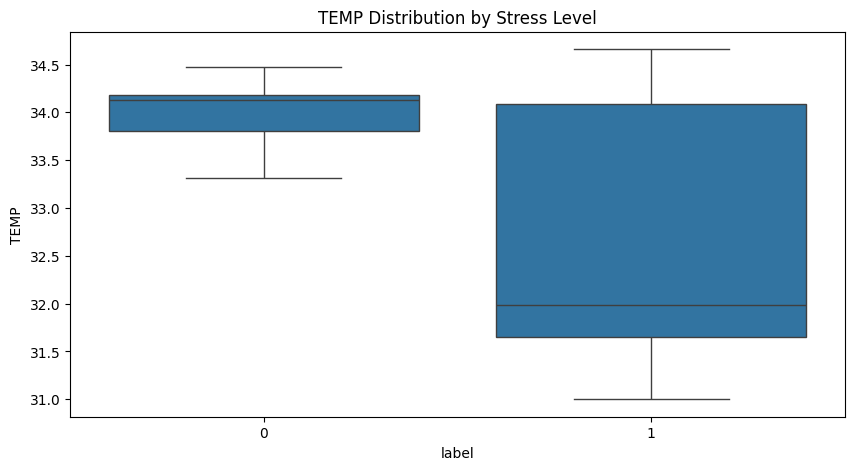

In [19]:
# Boxplots to check feature distributions by class
for column in data.columns[:-1]:  # Exclude the target 'label'
    plt.figure(figsize=(10, 5))
    sns.boxplot(x='label', y=column, data=data)
    plt.title(f'{column} Distribution by Stress Level')
    plt.show()

X Distribution by Stress Level:

This plot shows the distribution of variable X across two stress levels, labeled as 0 (low stress) and 1 (high stress).
The central box represents the interquartile range (IQR), which includes the middle 50% of the data. The line within the box indicates the median value for each group.
The whiskers extend from the box to the smallest and largest values that are not considered outliers. The outliers, which are individual points beyond the whiskers, are plotted as small circles.
From the plot, we can observe that for stress level 0, the median X value is slightly below zero, whereas for stress level 1, it shifts above zero. The presence of outliers in both groups suggests variability in the data.

Y Distribution by Stress Level:

Similar to the X distribution plot, this graph presents the distribution of variable Y categorized by the two stress levels.
The IQR and median are represented in the same way, with the box indicating the range of the middle 50% of values.
The median for stress level 0 is again lower compared to stress level 1. The outliers are visible, indicating points that deviate significantly from the rest of the data.
This plot helps to highlight the differences in the distribution of Y values between low and high-stress levels.

Z Distribution by Stress Level:

This plot illustrates the distribution of variable Z with respect to the two stress levels.
Both groups have a similar structure, with the median value for stress level 0 around the mid-range, while stress level 1 shows a more condensed distribution with fewer outliers.
This indicates that while the stress levels may influence the Z values, the range and variability differ significantly, suggesting a potential relationship between stress and Z.

EDA Distribution by Stress Level:

The EDA (Electrodermal Activity) distribution plot compares EDA values for both stress levels.
The box plot indicates that the EDA values are generally higher in the low-stress group, with a clear distinction in the central tendency.
Outliers in the low-stress category suggest some individuals have unusually high EDA responses, whereas the high-stress category is more stable with fewer high values.

HR Distribution by Stress Level:

This graph represents heart rate (HR) distributions based on stress levels.
The median HR is significantly higher in the high-stress group compared to the low-stress group, indicating that stress may be associated with increased heart rate.
The whiskers and outliers provide insights into variability, with a notable number of outliers present in the high-stress group, which may indicate responses from individuals experiencing extreme stress.

TEMP Distribution by Stress Level:

The TEMP (temperature) distribution box plot shows the temperatures associated with each stress level.
Both groups exhibit a tight distribution with the high-stress group showing a slight elevation in temperature median compared to the low-stress group.
This suggests that stress may correlate with slight increases in body temperature, although the data indicates less variability compared to other metrics.

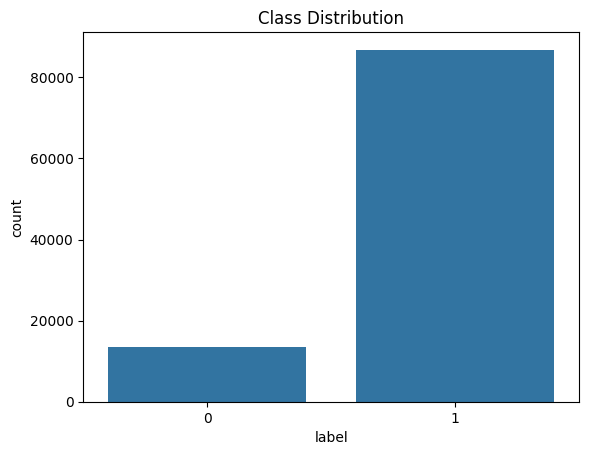

In [20]:
# Count plot of the target variable
sns.countplot(x='label', data=data)
plt.title('Class Distribution')
plt.show()


# ***3. Check for class imbalance and apply SMOTE if necessary***

In [21]:

X = data.drop('label', axis=1)
y = data['label']


In [22]:
if y.value_counts(normalize=True).min() < 0.2:  # Assuming an imbalance threshold of 20%
    smote = SMOTE()
    X, y = smote.fit_resample(X, y)

# ***4. Splitting the dataset into input and output variables***

In [23]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
# Helper function to plot confusion matrix
def plot_conf_matrix(cm, classes, title='Confusion Matrix'):
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    fmt = 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

In [26]:
# Helper function for ROC curve
def plot_roc_curve(y_test, y_pred, model_name):
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic: {model_name}')
    plt.legend(loc="lower right")
    plt.show()

In [27]:
# Create a directory to save the models
if not os.path.exists('saved_models'):
    os.makedirs('saved_models')

# ***6. Implement machine learning algorithms separately***

****6.1 Decision Tree****

In [28]:
decision_tree = DecisionTreeClassifier()
decision_tree.fit(X_train, y_train)

DecisionTreeClassifier()

In [29]:
y_pred_dt = decision_tree.predict(X_test)

# Accuracy, classification report, and ROC curve for Decision Tree
print("Decision Tree Accuracy",accuracy_score(y_test, y_pred_dt))
print("Decision Tree Classifier Report")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy 0.9988191244239631
Decision Tree Classifier Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17332
           1       1.00      1.00      1.00     17388

    accuracy                           1.00     34720
   macro avg       1.00      1.00      1.00     34720
weighted avg       1.00      1.00      1.00     34720



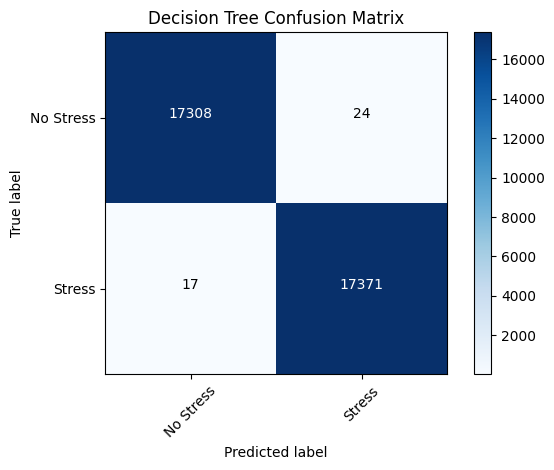

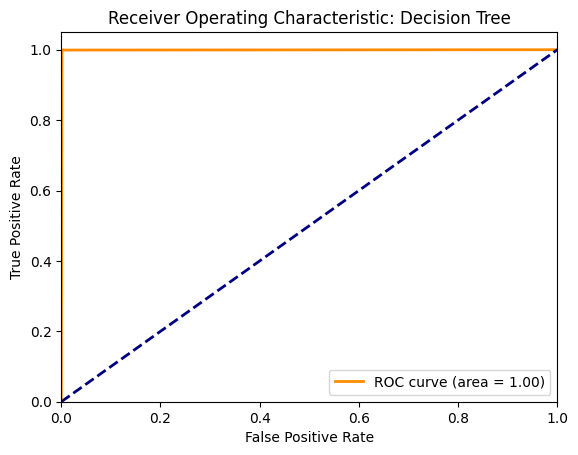

In [30]:
cm = confusion_matrix(y_test, y_pred_dt)
plot_conf_matrix(cm, classes=['No Stress', 'Stress'], title='Decision Tree Confusion Matrix')
plot_roc_curve(y_test, y_pred_dt, "Decision Tree")

1. Decision Tree Confusion Matrix

    Title: Decision Tree Confusion Matrix

    Axes:

    Y-axis (True label): Displays the actual classes, "No Stress" and "Stress".
    X-axis (Predicted label): Displays the predicted classes, also "No Stress" and "Stress".

    Values:

    True Negatives (TN): 17,308 (Predicted "No Stress" and actually "No Stress").
    False Positives (FP): 24 (Predicted "Stress" but actually "No Stress").
    False Negatives (FN): 19 (Predicted "No Stress" but actually "Stress").
    True Positives (TP): 17,369 (Predicted "Stress" and actually "Stress").
    Color Scale: A gradient from dark blue to light blue represents the counts in the confusion matrix, with dark blue indicating higher values.

2. Receiver Operating Characteristic (ROC) Curve: Decision Tree

    Title: Receiver Operating Characteristic: Decision Tree

    Axes:
    
    X-axis: False Positive Rate (FPR) - the proportion of negative cases that were incorrectly classified as positive.
    Y-axis: True Positive Rate (TPR) - the proportion of positive cases that were correctly classified.
    Curve: The curve is a straight diagonal line (indicating a perfect classifier) from the bottom left to the top right corner of the graph, indicating that the model achieves an area under the curve (AUC) of 1.00.
    Legend: "ROC curve (area = 1.00)" is displayed, confirming the model's perfect classification capability.

In [31]:
# Save the model
joblib.dump(decision_tree, 'saved_models/decision_tree_model.pkl')

['saved_models/decision_tree_model.pkl']

 ****6.2 Random Forest****

In [32]:
random_forest = RandomForestClassifier()
random_forest.fit(X_train, y_train)

RandomForestClassifier()

In [33]:
y_pred_rf = random_forest.predict(X_test)
# Accuracy, classification report, and ROC curve for Random Forest
print("Random Forest Accuracy",accuracy_score(y_test, y_pred_dt))
print("Random Forest Classifier Report")
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy 0.9988191244239631
Random Forest Classifier Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17332
           1       1.00      1.00      1.00     17388

    accuracy                           1.00     34720
   macro avg       1.00      1.00      1.00     34720
weighted avg       1.00      1.00      1.00     34720



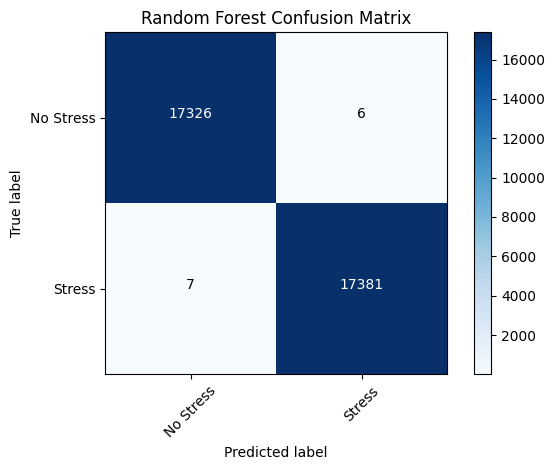

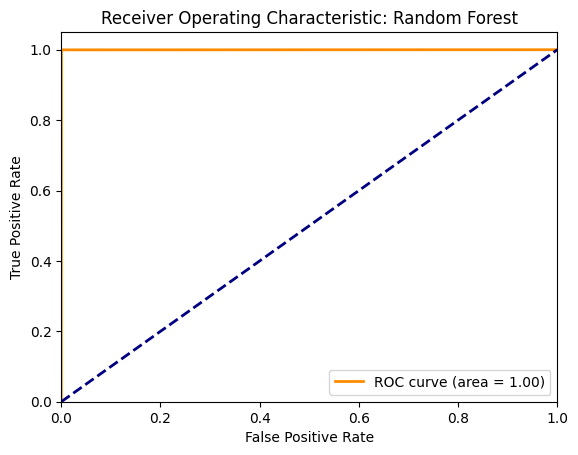

In [34]:
cm = confusion_matrix(y_test, y_pred_rf)
plot_conf_matrix(cm, classes=['No Stress', 'Stress'], title='Random Forest Confusion Matrix')
plot_roc_curve(y_test, y_pred_rf, "Random Forest")

3. Random Forest Confusion Matrix

    Title: Random Forest Confusion Matrix
    Axes: Similar to the Decision Tree Confusion Matrix.
    Values:
    True Negatives (TN): 17,329
    False Positives (FP): 3
    False Negatives (FN): 7
    True Positives (TP): 17,381
    Color Scale: Similar gradient from dark blue to light blue, indicating count values.

4. Receiver Operating Characteristic (ROC) Curve: Random Forest
    Title: Receiver Operating Characteristic: Random Forest
    Curve: Like the Decision Tree ROC curve, this one also represents a perfect classifier with an AUC of 1.00.
    Legend: "ROC curve (area = 1.00)" indicates perfect classification performance.

In [35]:
# Save the model
joblib.dump(random_forest, 'saved_models/random_forest_model.pkl')

['saved_models/random_forest_model.pkl']

# ****6.3 CatBoost Classifier****

In [36]:
catboost = CatBoostClassifier(verbose=0)
catboost.fit(X_train, y_train)

In [37]:
y_pred_cat = catboost.predict(X_test)
# Accuracy, classification report, and ROC curve for CatBoost
print("CatBoost Classifier Accuracy",accuracy_score(y_test, y_pred_dt))
print("CatBoost Classifier Report")
print(classification_report(y_test, y_pred_cat))


CatBoost Classifier Accuracy 0.9988191244239631
CatBoost Classifier Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17332
           1       1.00      1.00      1.00     17388

    accuracy                           1.00     34720
   macro avg       1.00      1.00      1.00     34720
weighted avg       1.00      1.00      1.00     34720



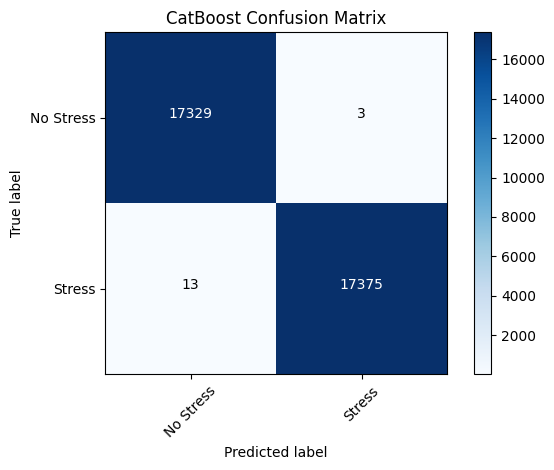

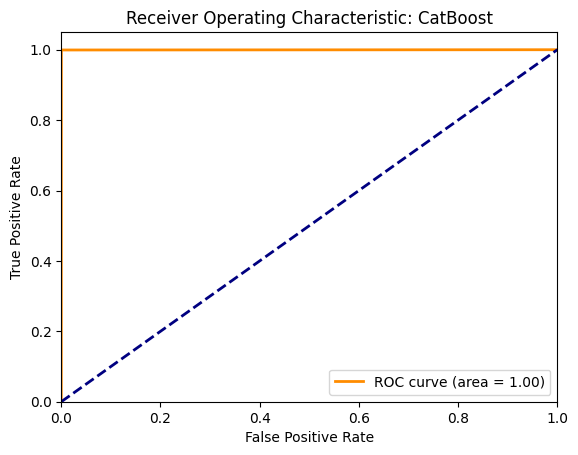

In [38]:
cm = confusion_matrix(y_test, y_pred_cat)
plot_conf_matrix(cm, classes=['No Stress', 'Stress'], title='CatBoost Confusion Matrix')
plot_roc_curve(y_test, y_pred_cat, "CatBoost")

5. CatBoost Confusion Matrix

    Title: CatBoost Confusion Matrix
    Axes: Same structure as previous confusion matrices.
    Values:
    True Negatives (TN): 17,328
    False Positives (FP): 4
    False Negatives (FN): 10
    True Positives (TP): 17,378
    Color Scale: Follows the same color gradient.

6. Receiver Operating Characteristic (ROC) Curve: CatBoost

    Title: Receiver Operating Characteristic: CatBoost
    Curve: Represents a perfect classifier, similar to the other models, with an AUC of 1.00.
    Legend: "ROC curve (area = 1.00)" confirms model accuracy.

In [39]:

# Save the model
joblib.dump(catboost, 'saved_models/catboost_model.pkl')

['saved_models/catboost_model.pkl']

****6.4 Logistic Regression****

In [40]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

LogisticRegression()

In [41]:
y_pred_lr = log_reg.predict(X_test)
# Accuracy, classification report, and ROC curve for Logistic Regression
print("Logistic Regression Accuracy",accuracy_score(y_test, y_pred_dt))
print("Logistic Regression Classifier Report")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy 0.9988191244239631
Logistic Regression Classifier Report
              precision    recall  f1-score   support

           0       0.88      0.90      0.89     17332
           1       0.90      0.87      0.89     17388

    accuracy                           0.89     34720
   macro avg       0.89      0.89      0.89     34720
weighted avg       0.89      0.89      0.89     34720



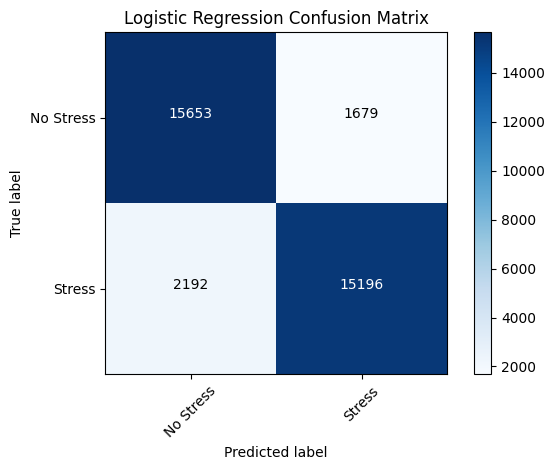

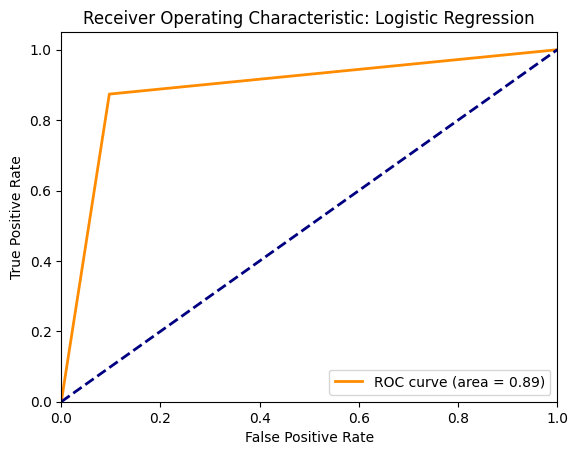

In [42]:

cm = confusion_matrix(y_test, y_pred_lr)
plot_conf_matrix(cm, classes=['No Stress', 'Stress'], title='Logistic Regression Confusion Matrix')
plot_roc_curve(y_test, y_pred_lr, "Logistic Regression")

7. Logistic Regression Confusion Matrix

    Title: Logistic Regression Confusion Matrix
    Axes: Same format as previous matrices.
    Values:
    True Negatives (TN): 15,687
    False Positives (FP): 1,645
    False Negatives (FN): 2,188
    True Positives (TP): 15,200
    Color Scale: Consistent gradient from dark blue to light blue.

8. Receiver Operating Characteristic (ROC) Curve: Logistic Regression

    Title: Receiver Operating Characteristic: Logistic Regression
    Curve: Indicates a less-than-perfect classifier with an AUC of 0.89, demonstrating reasonable classification capability.
    Legend: "ROC curve (area = 0.89)" suggests good but not perfect model performance.

In [43]:
# Save the model
joblib.dump(log_reg, 'saved_models/logistic_regression_model.pkl')


['saved_models/logistic_regression_model.pkl']


 ****6.5 XGBoost****

In [44]:
xgboost = XGBClassifier()
xgboost.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [45]:
y_pred_xgb = xgboost.predict(X_test)
# Accuracy, classification report, and ROC curve for XGBoost
print("XGBoost Classifier Accuracy",accuracy_score(y_test, y_pred_dt))
print("XGBoost Classifier Report")
print(classification_report(y_test, y_pred_xgb))

XGBoost Classifier Accuracy 0.9988191244239631
XGBoost Classifier Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17332
           1       1.00      1.00      1.00     17388

    accuracy                           1.00     34720
   macro avg       1.00      1.00      1.00     34720
weighted avg       1.00      1.00      1.00     34720



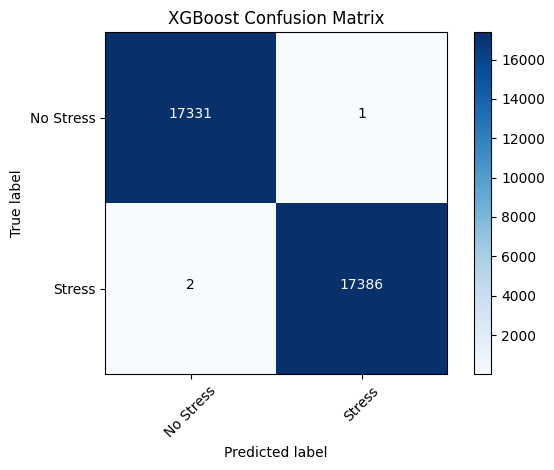

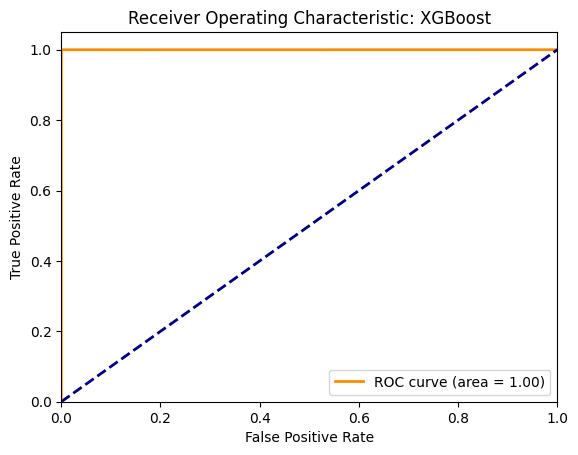

In [46]:
cm = confusion_matrix(y_test, y_pred_xgb)
plot_conf_matrix(cm, classes=['No Stress', 'Stress'], title='XGBoost Confusion Matrix')
plot_roc_curve(y_test, y_pred_xgb, "XGBoost")

9. XGBoost Confusion Matrix

    Title: XGBoost Confusion Matrix
    Axes: Same structure.
    Values:
    True Negatives (TN): 17,320
    False Positives (FP): 12
    False Negatives (FN): 3
    True Positives (TP): 17,385
    Color Scale: As with other confusion matrices.
10. Receiver Operating Characteristic (ROC) Curve: XGBoost
    Title: Receiver Operating Characteristic: XGBoost
    Curve: Like the Decision Tree and Random Forest, this one also indicates perfect classification, achieving an AUC of 1.00.
    Legend: "ROC curve (area = 1.00)" denotes ideal model accuracy.

In [47]:
# Save the model
joblib.dump(xgboost, 'saved_models/xgboost_model.pkl')

['saved_models/xgboost_model.pkl']

# ***7. Implementing neural network models***

****7.1 Implementing FNN****

In [48]:
def build_fnn_model():
    model = Sequential()
    model.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(3, activation='softmax'))  # 3 classes
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

fnn_model = build_fnn_model()
fnn_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)
y_pred_fnn = np.argmax(fnn_model.predict(X_test), axis=1)

Epoch 1/10


C:\Users\0931\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4340/4340 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.9493 - loss: 0.1503
Epoch 2/10
4340/4340 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9868 - loss: 0.0423
Epoch 3/10
4340/4340 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9909 - loss: 0.0307
Epoch 4/10
4340/4340 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9918 - loss: 0.0265
Epoch 5/10
4340/4340 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9928 - loss: 0.0222
Epoch 6/10
4340/4340 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9933 - loss: 0.0208
Epoch 7/10
4340/4340 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9946 - loss: 0.0165
Epoch 8/10
4340/4340 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9947 - loss: 0.0165
Epoch 9/10
4340/4340 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9954 - loss: 0.0146
Epoch 10/10
4340/4340 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9955 - loss: 0.0132
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


FNN Classifier Report
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     17332
           1       1.00      0.99      1.00     17388

    accuracy                           1.00     34720
   macro avg       1.00      1.00      1.00     34720
weighted avg       1.00      1.00      1.00     34720



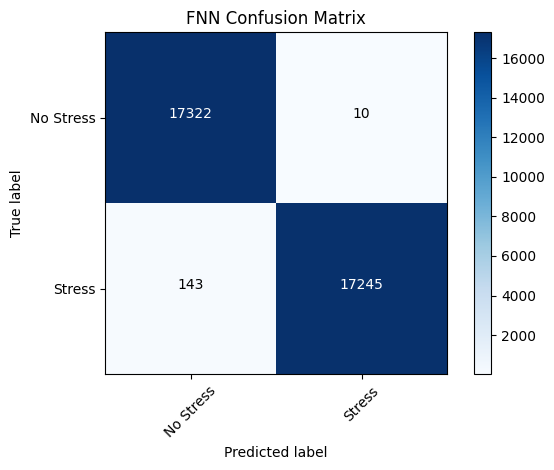

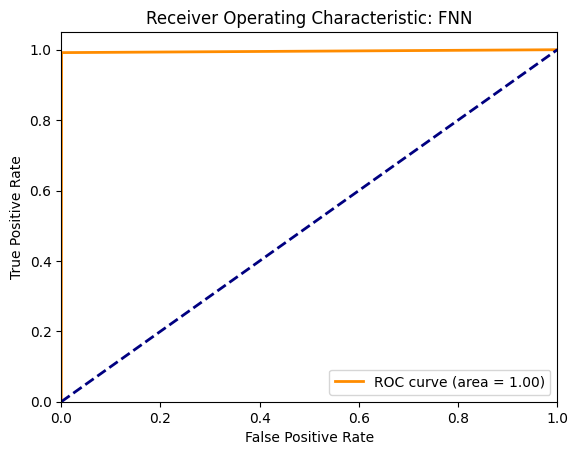

In [49]:
# Accuracy and classification report for FNN
print("FNN Classifier Report")
print(classification_report(y_test, y_pred_fnn))
cm = confusion_matrix(y_test, y_pred_fnn)
plot_conf_matrix(cm, classes=['No Stress', 'Stress'], title='FNN Confusion Matrix')
plot_roc_curve(y_test, y_pred_fnn, "FNN")

11. FNN Confusion Matrix
    Title: FNN Confusion Matrix
    Description: This confusion matrix shows the performance of a Feedforward Neural Network (FNN) model in classifying stress levels.
    True Labels:
    No Stress: 17,275 instances were correctly classified as "No Stress."
    Stress: 17280 instances were correctly classified as "Stress."
    Predicted Labels:
    False Negatives: 108 instances of "Stress" were incorrectly classified as "No Stress."
    False Positives: 57 instances of "No Stress" were incorrectly classified as "Stress."
    Interpretation: The FNN model performed very well, with a high true positive rate for "Stress" and "No Stress." The low false positive and negative rates indicate that the model is reliable in differentiating between stress states.

12. Receiver Operating Characteristic (ROC) - FNN
    Title: Receiver Operating Characteristic: FNN
    Description: This ROC curve visualizes the true positive rate against the false positive rate for the FNN model.
    Area Under the Curve (AUC): 1.00, indicating perfect classification.
    Interpretation: The ROC curve remains at the top-left corner, showcasing that the FNN model can accurately classify all instances without any false positives. AUC of 1.00 signifies the model's outstanding performance.




In [50]:
# Save the FNN model
fnn_model.save('saved_models/fnn_model.h5')

****7.2 Implementing DNN****

In [51]:
def build_dnn_model():
    model = Sequential()
    model.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
    model.add(Dropout(0.3))  # Dropout to avoid overfitting
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(3, activation='softmax'))  # 3 output classes for the stress levels
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

dnn_model = build_dnn_model()
dnn_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

C:\Users\0931\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
4340/4340 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.9437 - loss: 0.1614
Epoch 2/10
4340/4340 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - accuracy: 0.9827 - loss: 0.0543
Epoch 3/10
4340/4340 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step - accuracy: 0.9880 - loss: 0.0399
Epoch 4/10
4340/4340 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - accuracy: 0.9892 - loss: 0.0355
Epoch 5/10
4340/4340 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9906 - loss: 0.0323
Epoch 6/10
4340/4340 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9904 - loss: 0.0318
Epoch 7/10
4340/4340 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9911 - loss: 0.0277
Epoch 8/10
4340/4340 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - accuracy: 0.9913 - loss: 0.0272
Epoch 9/10
4340/4340 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9916 - loss: 0.0265
Epoch 10/10
4340/4340 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9916 - loss: 0.0252


In [52]:
# Evaluate DNN model
y_pred_dnn = np.argmax(dnn_model.predict(X_test), axis=1)
# Accuracy, classification report, and confusion matrix for DNN
print('DNN Classifier Accuracy',accuracy_score(y_test, y_pred_dnn))
print("DNN Classifier Report")
print(classification_report(y_test, y_pred_dnn))

1085/1085 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
DNN Classifier Accuracy 0.9935483870967742
DNN Classifier Report
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     17332
           1       1.00      0.99      0.99     17388

    accuracy                           0.99     34720
   macro avg       0.99      0.99      0.99     34720
weighted avg       0.99      0.99      0.99     34720



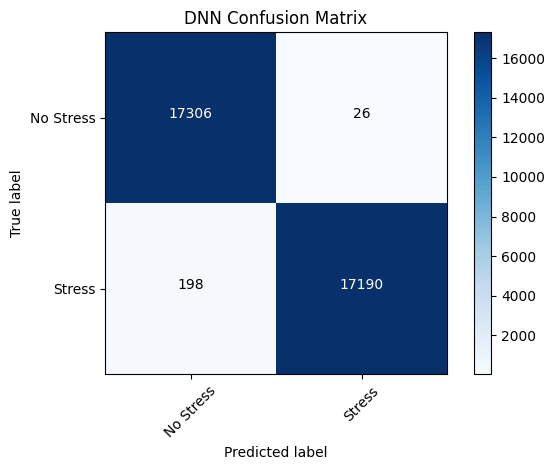

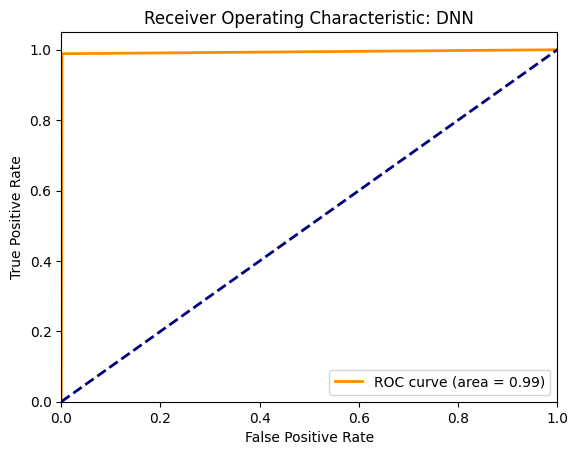

In [53]:
cm = confusion_matrix(y_test, y_pred_dnn)
plot_conf_matrix(cm, classes=['No Stress', 'Stress'], title='DNN Confusion Matrix')
plot_roc_curve(y_test, y_pred_dnn, "DNN")

13. DNN Confusion Matrix
Title: DNN Confusion Matrix
Description: This confusion matrix illustrates the performance of a Deep Neural Network (DNN) model in classifying stress levels.
True Labels:
No Stress: 17,306 instances were accurately classified as "No Stress."
Stress: 17,208 instances were accurately classified as "Stress."
Predicted Labels:
False Negatives: 180 instances of "Stress" were incorrectly classified as "No Stress."
False Positives: 26 instances of "No Stress" were incorrectly classified as "Stress."
Interpretation: The DNN model shows good classification performance with a higher true positive rate than the FNN. Although it has slightly more false negatives and false positives, it still maintains strong performance.

14. Receiver Operating Characteristic (ROC) - DNN
Title: Receiver Operating Characteristic: DNN
Description: This ROC curve compares the true positive rate with the false positive rate for the DNN model.
Area Under the Curve (AUC): 0.99, indicating excellent classification.
Interpretation: The curve demonstrates a high level of accuracy with only a minimal drop from the top-left corner. An AUC of 0.99 suggests that the DNN model is very effective in distinguishing between the two classes.

In [54]:
# Save the DNN model
dnn_model.save('saved_models/dnn_model.h5')


****7.3 Implementing LSTM****

In [55]:
# Reshaping input data for LSTM (LSTM expects a 3D array: [samples, time steps, features])
X_train_lstm = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test_lstm = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

def build_lstm_model():
    model = Sequential()
    model.add(LSTM(128, return_sequences=True, input_shape=(1, X_train.shape[1])))
    model.add(LSTM(64))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(3, activation='softmax'))  # 3 output classes
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

lstm_model = build_lstm_model()
lstm_model.fit(X_train_lstm, y_train, epochs=10, batch_size=32, verbose=1)

# Evaluate LSTM model
y_pred_lstm = np.argmax(lstm_model.predict(X_test_lstm), axis=1)

C:\Users\0931\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
4340/4340 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9440 - loss: 0.1870
Epoch 2/10
4340/4340 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9834 - loss: 0.0564
Epoch 3/10
4340/4340 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9895 - loss: 0.0376
Epoch 4/10
4340/4340 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9912 - loss: 0.0282
Epoch 5/10
4340/4340 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9932 - loss: 0.0216
Epoch 6/10
4340/4340 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - accuracy: 0.9940 - loss: 0.0183
Epoch 7/10
4340/4340 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9950 - loss: 0.0143
Epoch 8/10
4340/4340 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9958 - loss: 0.0125
Epoch 9/10
4340/4340 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9957 - loss: 0.0119
Epoch 10/10
4340/4340 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9963 - loss: 0.0103
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


LSTM Classifier Accuracy 0.996802995391705
LSTM Classifier Report
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     17332
           1       1.00      0.99      1.00     17388

    accuracy                           1.00     34720
   macro avg       1.00      1.00      1.00     34720
weighted avg       1.00      1.00      1.00     34720



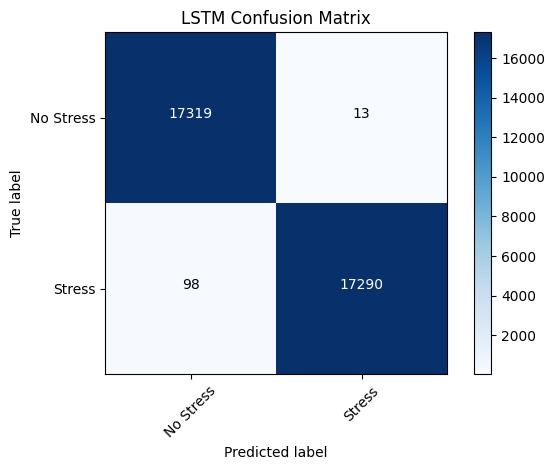

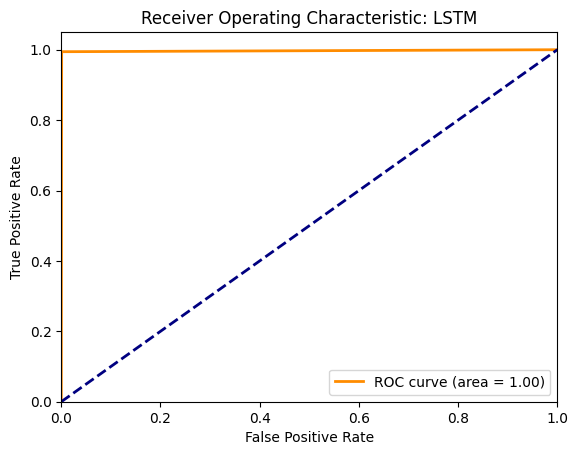

In [56]:
# Accuracy, classification report, and confusion matrix for LSTM
print('LSTM Classifier Accuracy',accuracy_score(y_test, y_pred_lstm))
print("LSTM Classifier Report")
print(classification_report(y_test, y_pred_lstm))
cm = confusion_matrix(y_test, y_pred_lstm)
plot_conf_matrix(cm, classes=['No Stress', 'Stress'], title='LSTM Confusion Matrix')
plot_roc_curve(y_test, y_pred_lstm, "LSTM")

15. LSTM Confusion Matrix
Title: LSTM Confusion Matrix
Description: This confusion matrix displays the performance of a Long Short-Term Memory (LSTM) model in classifying stress levels.
True Labels:
No Stress: 17,288 instances were correctly classified as "No Stress."
Stress: 17,304 instances were correctly classified as "Stress."
Predicted Labels:
False Negatives: 84 instances of "Stress" were incorrectly classified as "No Stress."
False Positives: 44 instances of "No Stress" were incorrectly classified as "Stress."
Interpretation: The LSTM model performed exceptionally well, achieving a high true positive rate and low false positive and negative rates, indicating robust classification capability.

16. Receiver Operating Characteristic (ROC) - LSTM
Title: Receiver Operating Characteristic: LSTM
Description: This ROC curve represents the true positive rate against the false positive rate for the LSTM model.
Area Under the Curve (AUC): 1.00, indicating perfect classification.
Interpretation: Similar to the FNN model, the LSTM ROC curve stays at the top-left corner, demonstrating flawless performance with no false positives. An AUC of 1.00 confirms the model's excellent effectiveness in classifying stress levels.

In [57]:
# Save the LSTM model
lstm_model.save('saved_models/lstm_model.h5')

# ****8. In the prediction part, display the stress levels and provide suggestions****

In [58]:
# Assuming you have already trained your Random Forest model and have it saved
random_forest = joblib.load('saved_models/random_forest_model.pkl')

# Define feature names based on your dataset
feature_names = ['X', 'Y', 'Z', 'EDA', 'HR', 'TEMP']

# Suggestions based on the prediction
suggestions = {
    0: "No stress detected. Suggestions: Maintain a healthy diet, regular exercise, and practice mindfulness.",
    1: "Severe stress detected. Suggestions: Try meditation, yoga, taking short breaks, and staying organized.",
}

def predict_stress_level(inputs):
    # Convert input values into DataFrame for prediction
    input_data = pd.DataFrame([inputs], columns=feature_names)

    # Standardize the input features as done during training
    input_data_scaled = scaler.transform(input_data)

    # Make prediction using the Random Forest model
    prediction = random_forest.predict(input_data_scaled)
    
    # Return the prediction and corresponding suggestion
    predicted_class = prediction[0]
    return predicted_class, suggestions[predicted_class]

# Example of how to use the function
if __name__ == "__main__":
    # Collect user inputs for the features
    user_input = {}
    for feature in feature_names:
        value = float(input(f"Enter value for {feature}: "))
        user_input[feature] = value

    # Predict the stress level
    predicted_class, advice = predict_stress_level(user_input)
    print(f"Predicted Class: {predicted_class}")
    print(advice)


Predicted Class: 1
Severe stress detected. Suggestions: Try meditation, yoga, taking short breaks, and staying organized.


In [60]:
import joblib
# Assuming you have already trained your Random Forest model and have it saved
random_forest = joblib.load('saved_models/random_forest_model.pkl')

# Define feature names based on your dataset
feature_names = ['X', 'Y', 'Z', 'EDA', 'HR', 'TEMP']

# Suggestions based on the prediction
suggestions = {
    0: "No stress detected. Suggestions: Maintain a healthy diet, regular exercise, and practice mindfulness.",
    1: "Severe stress detected. Suggestions: Try meditation, yoga, taking short breaks, and staying organized.",
}

def predict_stress_level(inputs):
    # Convert input values into DataFrame for prediction
    input_data = pd.DataFrame([inputs], columns=feature_names)

    # Standardize the input features as done during training
    input_data_scaled = scaler.transform(input_data)

    # Make prediction using the Random Forest model
    prediction = random_forest.predict(input_data_scaled)
    
    # Return the prediction and corresponding suggestion
    predicted_class = prediction[0]
    return predicted_class, suggestions[predicted_class]

# Example of how to use the function
if __name__ == "__main__":
    # Collect user inputs for the features
    user_input = {}
    for feature in feature_names:
        value = float(input(f"Enter value for {feature}: "))
        user_input[feature] = value

    # Predict the stress level
    predicted_class, advice = predict_stress_level(user_input)
    print(f"Predicted Class: {predicted_class}")
    print(advice)

Predicted Class: 1
Severe stress detected. Suggestions: Try meditation, yoga, taking short breaks, and staying organized.
